In [181]:
import numpy as np
import matplotlib.pyplot as plt

import mpl_config
import ode_models as odes

### Set up and solve ODE model

In [182]:
alpha = 1.5
beta = 1
delta = 1
gamma = 3
x0 = 1
y0 = 1
t = np.linspace(0, 20, 500)
X0 = [x0, y0]

lotkavolterra = odes.LotkaVolterra([alpha, beta, delta, gamma])
solution = lotkavolterra.solve(initial_conditions=X0, timepoints=t)

### Plot ODE solution

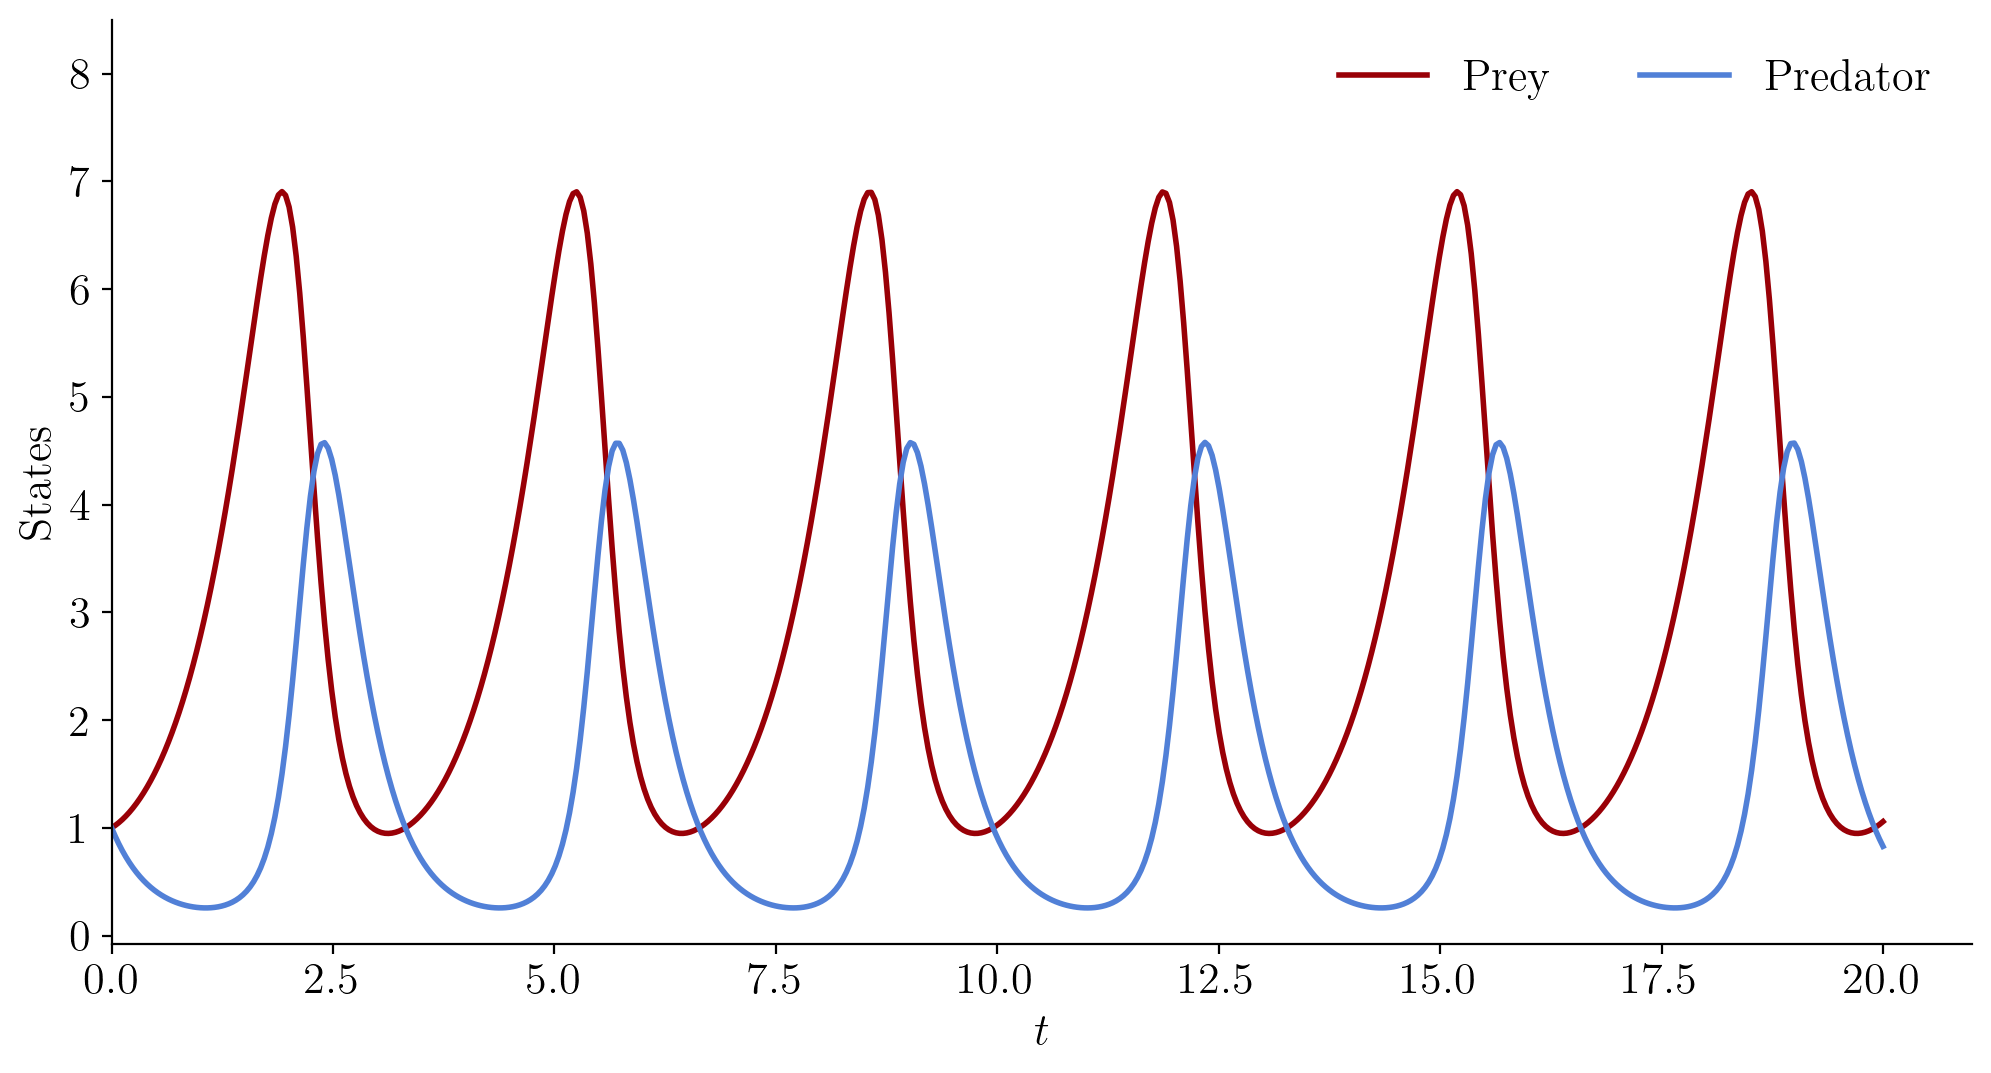

In [183]:
_, ax = lotkavolterra.plot(t, solution, ls="-")
ax.set_ylim(top=8.5)
ax.legend(loc="upper right", ncol=2)
plt.show()

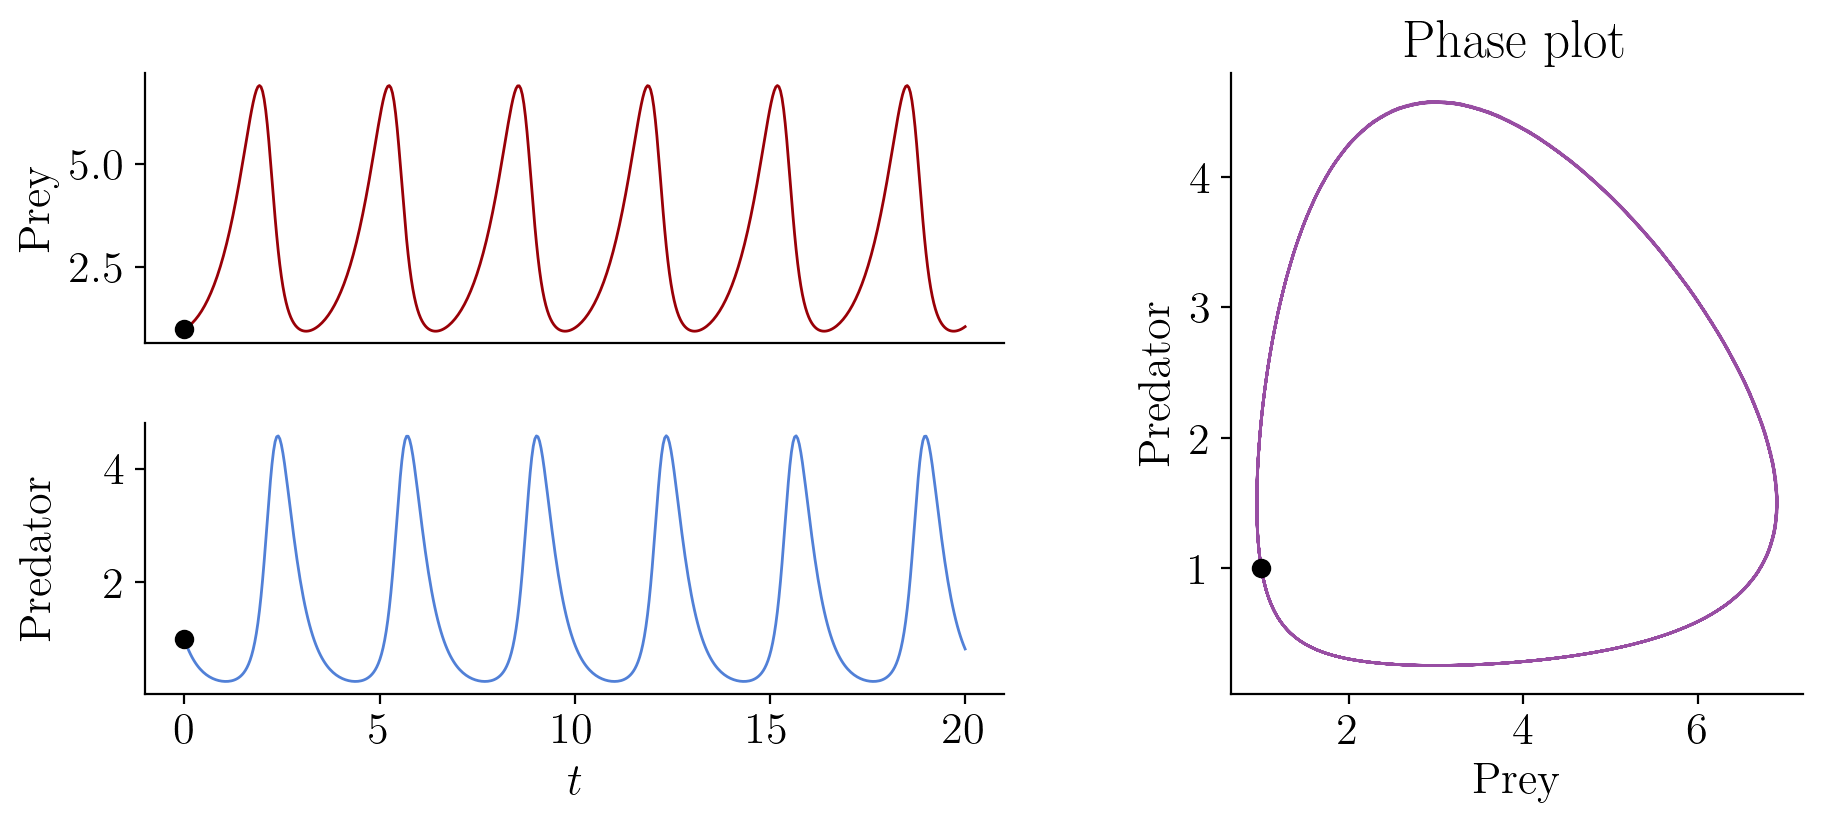

In [184]:
lotkavolterra.plot_phase(t, solution)
plt.show()

### Plot noised solutions

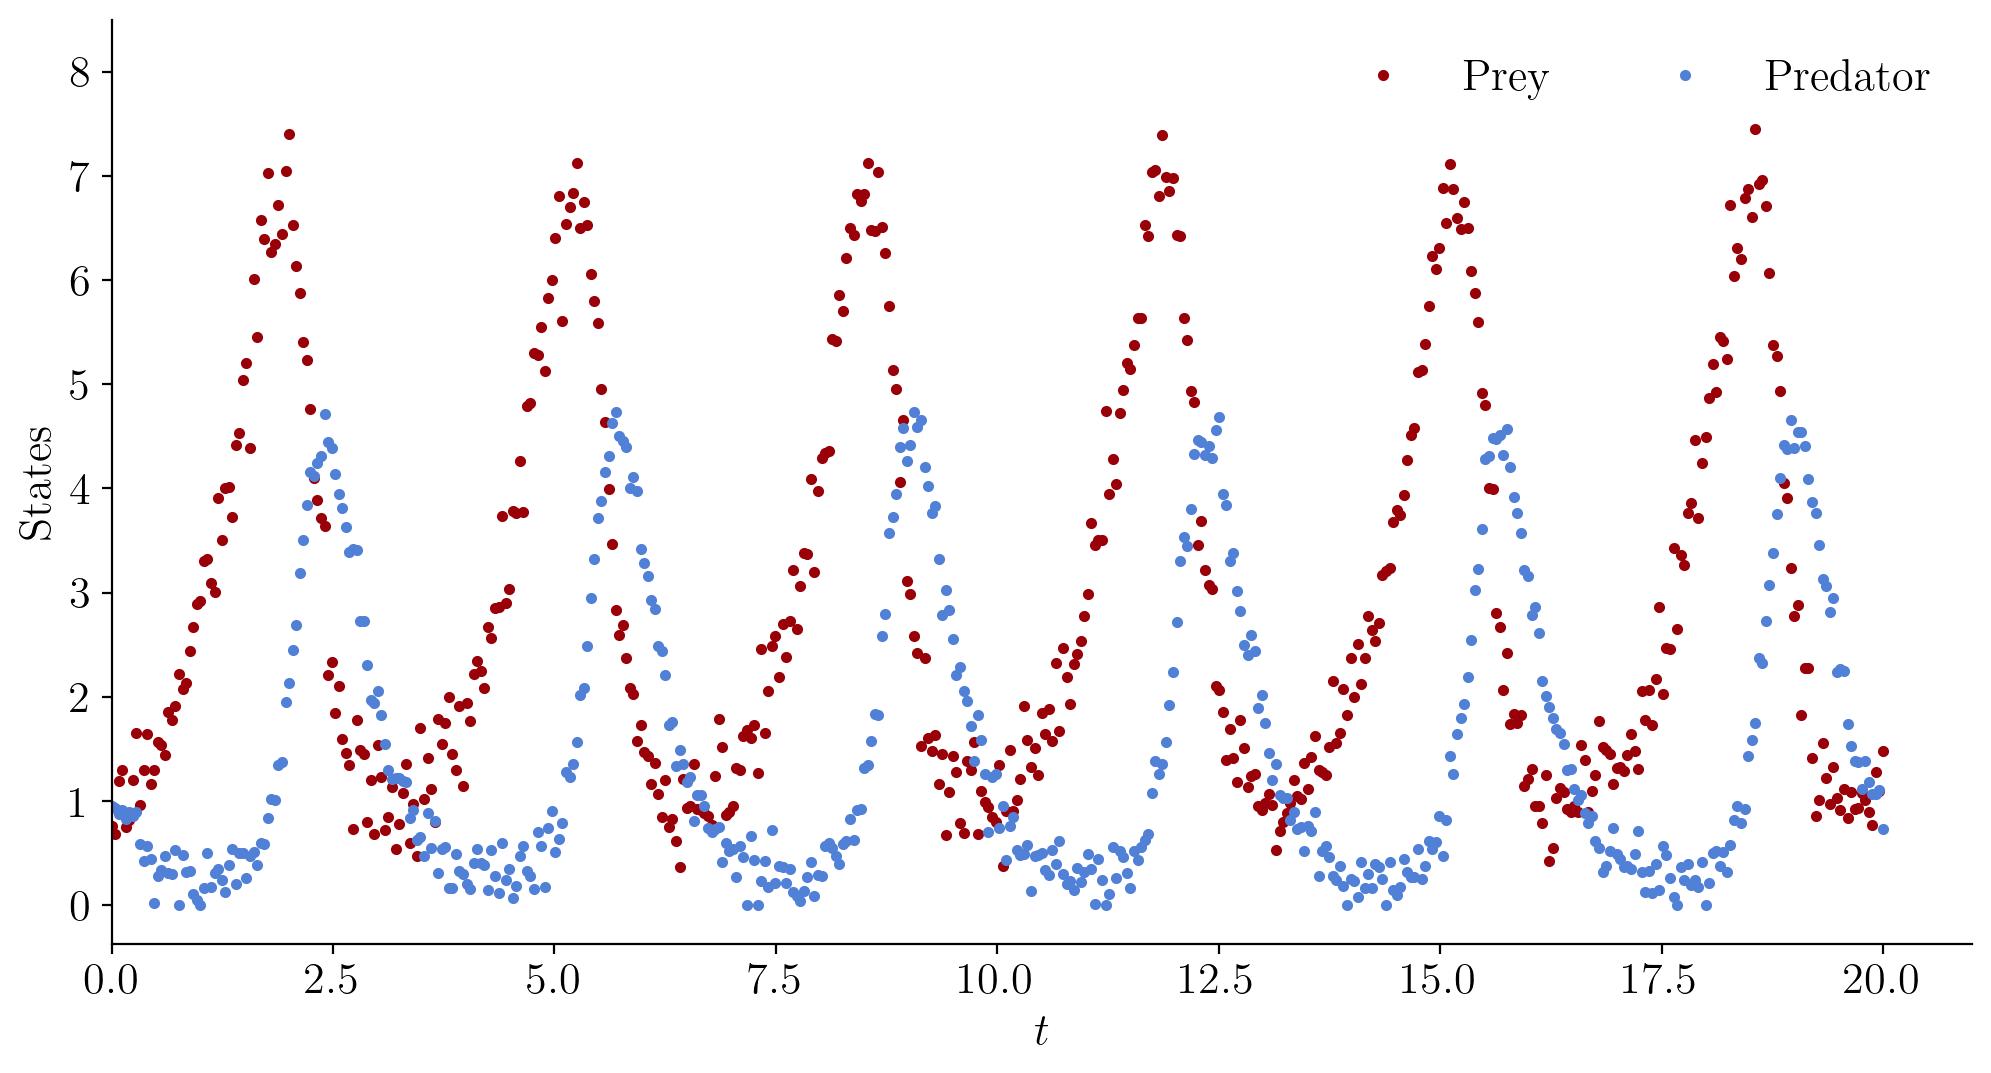

In [185]:
# TODO - Look into how much this noise is 
_, ax = lotkavolterra.plot(t, lotkavolterra.noise(solution, 0.10))
ax.set_ylim(top=8.5)
ax.legend(loc="upper right", ncol=2)
plt.show()

In [186]:
import gpytorch
import torch
import matplotlib.pyplot as plt
import numpy as np

from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ZeroMean
from gpytorch.kernels import ScaleKernel, RBFKernel, MaternKernel, PeriodicKernel
 

class ExactGPModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood,
                 constant_bounds=None, length_scale_bounds=None, kernel=None, mean = None):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        if mean == None:
            self.mean_module = ZeroMean()
        else:
            self.mean_module = mean
        if kernel == None:
            if constant_bounds and length_scale_bounds:
                self.covar_module = ScaleKernel(
                    RBFKernel(lengthscale_constraint=gpytorch.constraints.Interval(*length_scale_bounds)),
                    outputscale_constraint=gpytorch.constraints.Interval(*constant_bounds)
                )
            else:
                self.covar_module = ScaleKernel(RBFKernel())
        else:
            self.covar_module = kernel

            
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
def train(model, likelihood, train_x, train_y, training_iter=50):
    # Set into training mode
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Train over several iterations using the full training dataset each time
    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        # print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        #     i + 1, training_iter, loss.item(),
        #     model.covar_module.base_kernel.lengthscale.item(),
        #     model.likelihood.noise.item()
        # ))
        optimizer.step()

In [187]:
# predator, prey = torch.from_numpy(lotkavolterra.noise(solution, 0.10)[0]).float(), torch.from_numpy(lotkavolterra.noise(solution, 0.10)[1]).float()
predator, prey = torch.from_numpy(solution[0]).float(), torch.from_numpy(lotkavolterra.noise(solution, 0.10)[1]).float()

t = torch.from_numpy(t)

In [188]:
# Assuming time_domains_sampled[0] and snapshots_sampled[0] are numpy arrays
likelihood = GaussianLikelihood()
# Convert numpy arrays to float32 tensors:

torch_gp = ExactGPModel(
    t, predator, likelihood,
)

train(torch_gp, likelihood, t, predator, training_iter=1000)

In [189]:
torch_gp.eval()
with torch.no_grad():
    # Convert to float32
    y = torch_gp(t)
    ly = likelihood(y)
    mean_ly = ly.mean
    std_ly = ly.stddev

/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


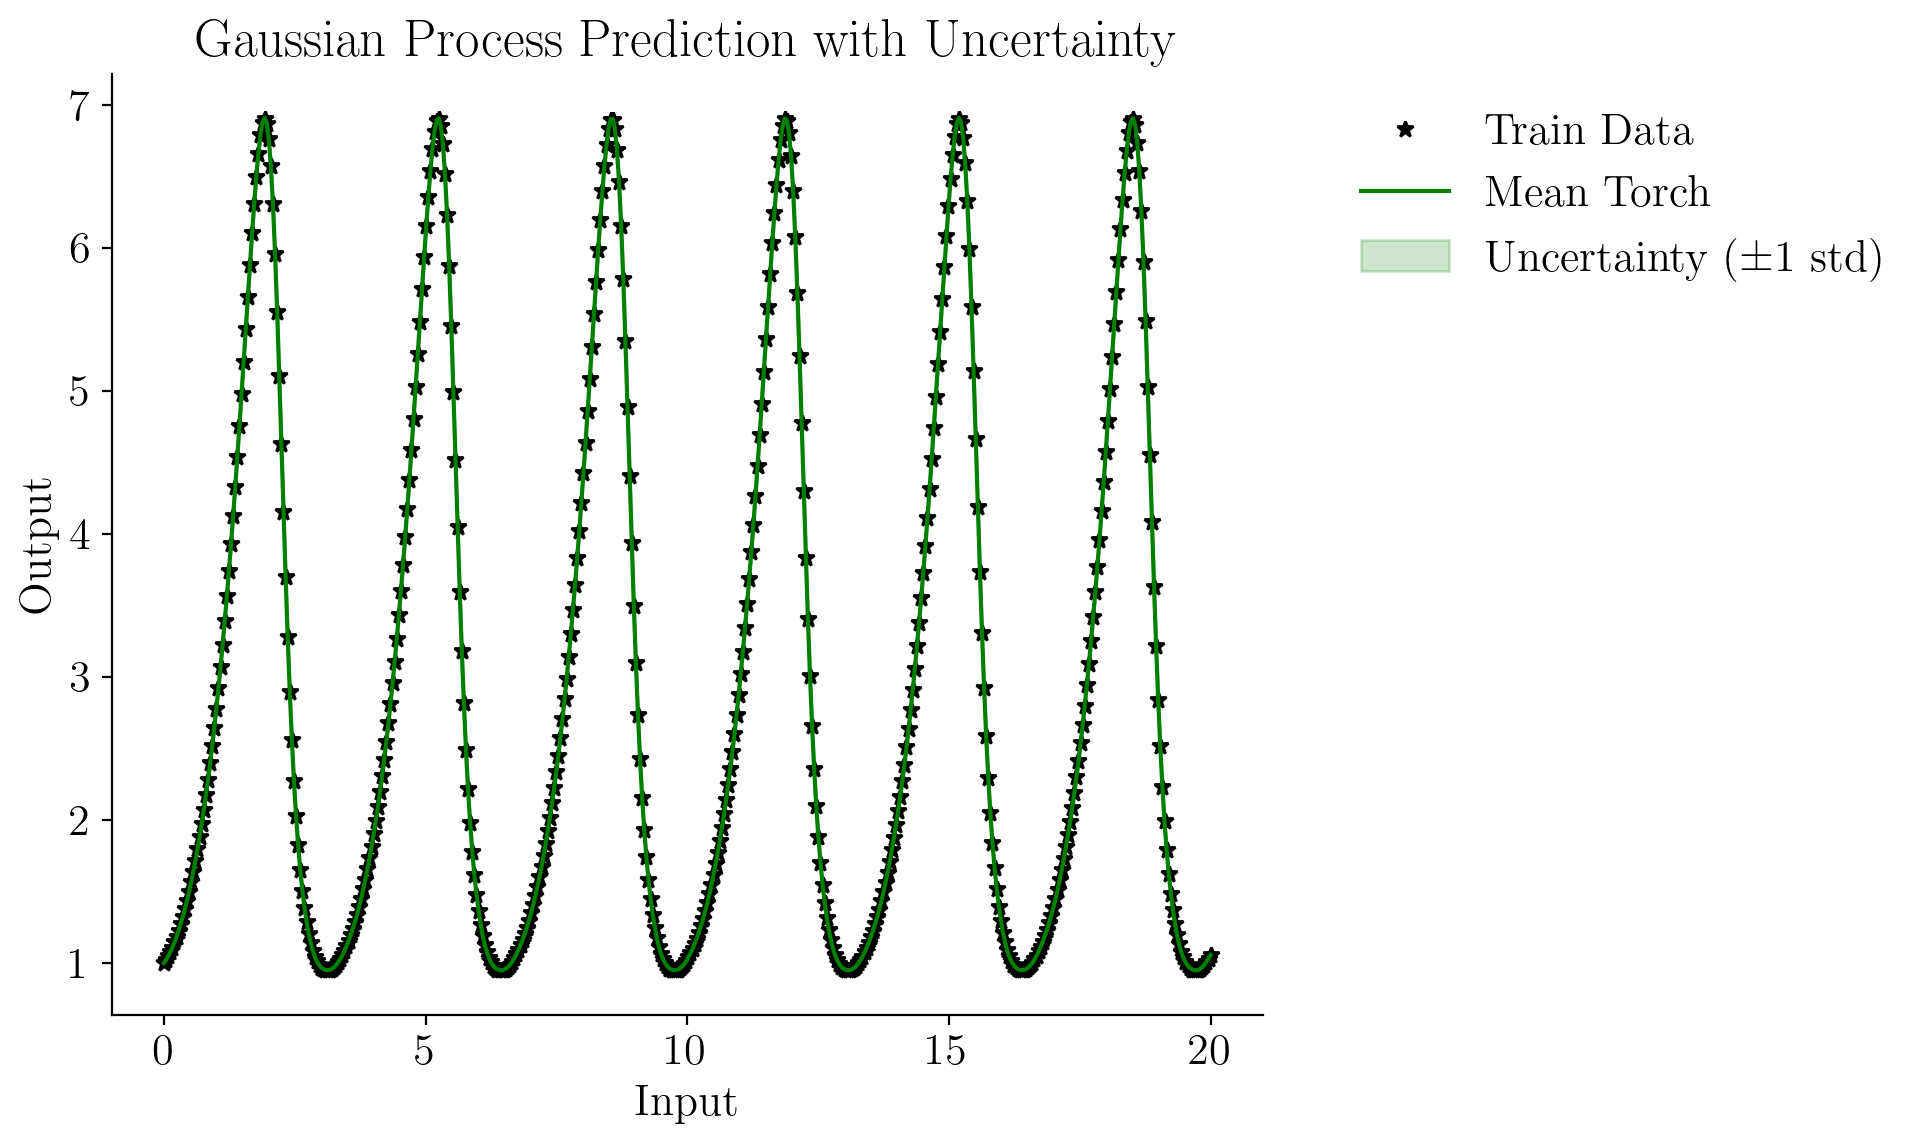

In [190]:
plt.figure(figsize=(10, 6))
plt.plot(t, predator, 'k*', label='Train Data')
plt.plot(t, mean_ly, 'g-', label='Mean Torch')
plt.fill_between(t, mean_ly - std_ly, mean_ly + std_ly, color='green', alpha=.2, label='Uncertainty (±1 std)')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Gaussian Process Prediction with Uncertainty')

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # Adjust layout to accommodate the external legend
plt.show()

### Experiment: Different Kernels and Data Sparsification

In [191]:
def uniformly_sparsify(x, y, factor=10):
    """Select every factor-th data point."""
    return x[::factor], y[::factor]

def randomly_sparsify(x, y, num_points=50):
    """Randomly select num_points data points."""
    indices = np.sort(np.random.choice(len(x), num_points, replace=False))
    return x[indices], y[indices]

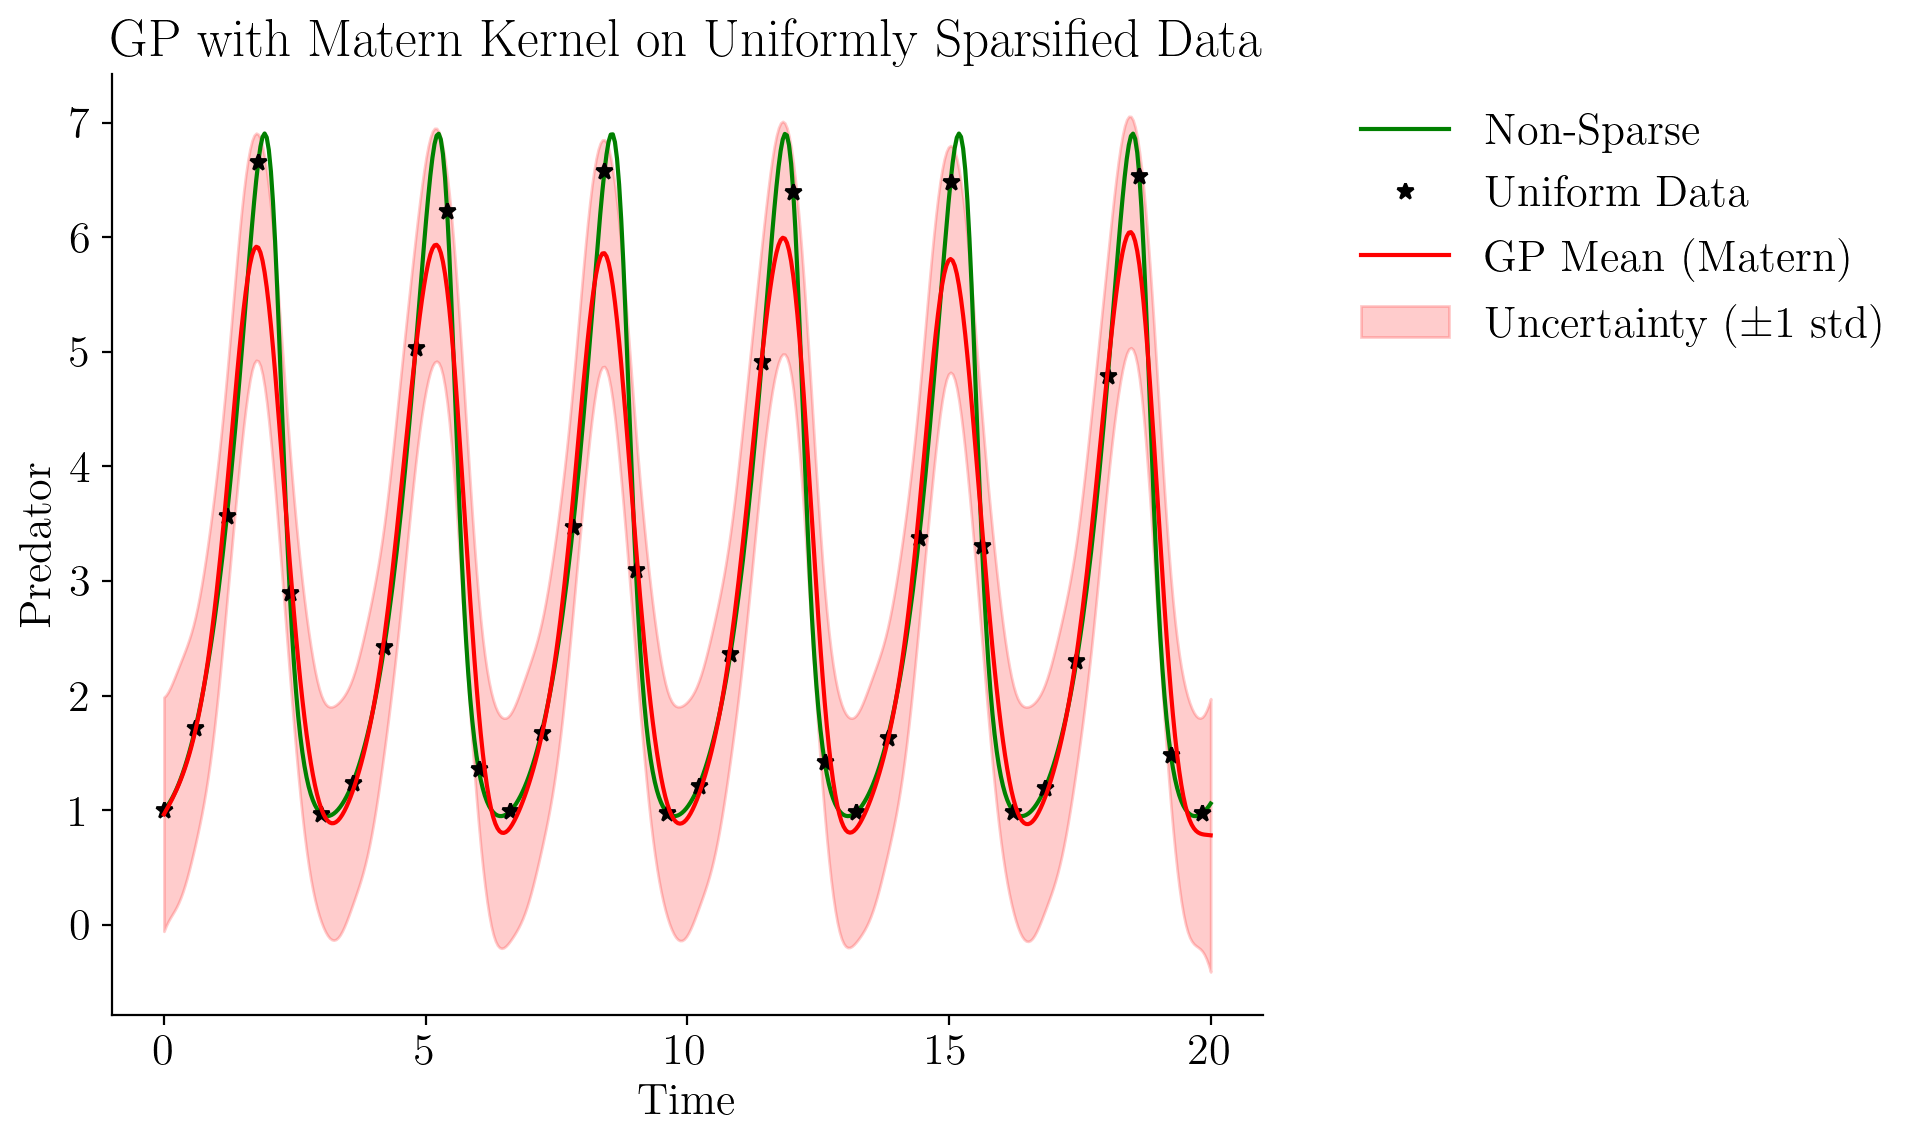

In [192]:
# Uniform sparsification experiment with a Matern kernel

# Uniformly sparsify the data (using the original numpy arrays)
t_uniform, predator_uniform = uniformly_sparsify(t, predator.numpy(), factor=15)

# Convert to torch tensors
# t_uniform_tensor = torch.from_numpy(t_uniform).float()
t_uniform_tensor = t_uniform
predator_uniform_tensor = torch.from_numpy(predator_uniform).float()

from gpytorch.kernels import MaternKernel

class ExactGPModelMatern(ExactGPModel):
    def __init__(self, train_x, train_y, likelihood,
                 constant_bounds=None, length_scale_bounds=None):
        super(ExactGPModelMatern, self).__init__(train_x, train_y, likelihood)
        self.mean_module = ZeroMean()
        if constant_bounds and length_scale_bounds:
            self.covar_module = ScaleKernel(
                MaternKernel(nu=2.5, lengthscale_constraint=gpytorch.constraints.Interval(*length_scale_bounds)),
                outputscale_constraint=gpytorch.constraints.Interval(*constant_bounds)
            )
        else:
            self.covar_module = ScaleKernel(MaternKernel(nu=2.5))

# Train GP with Matern kernel on uniformly sparsified data
likelihood_uniform = GaussianLikelihood()
model_uniform = ExactGPModelMatern(t_uniform_tensor, predator_uniform_tensor, likelihood_uniform)
train(model_uniform, likelihood_uniform, t_uniform_tensor, predator_uniform_tensor, training_iter=500)

model_uniform.eval()
with torch.no_grad():
    pred_uniform = model_uniform(t)
    likelihood_uniform_pred = likelihood_uniform(pred_uniform)
    mean_uniform = likelihood_uniform_pred.mean
    std_uniform = likelihood_uniform_pred.stddev

plt.figure(figsize=(10,6))
plt.plot(t, predator, 'g-', label="Non-Sparse")
plt.plot(t_uniform_tensor.numpy(), predator_uniform_tensor.numpy(), 'k*', label='Uniform Data')
plt.plot(t.numpy(), mean_uniform.numpy(), 'r-', label='GP Mean (Matern)')
plt.fill_between(t.numpy(), (mean_uniform - std_uniform).numpy(), 
                 (mean_uniform + std_uniform).numpy(), color='red', alpha=0.2, label='Uncertainty (±1 std)')
plt.title('GP with Matern Kernel on Uniformly Sparsified Data')
plt.xlabel('Time')
plt.ylabel('Predator')

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # Adjust layout to accommodate the external legend
plt.show()

In [196]:
# Random sparsification experiment with the default RBF kernel

# Randomly sparsify the data
import gpytorch.constraints


t_random, predator_random = randomly_sparsify(t, predator.numpy(), num_points=30)

# Convert to torch tensors
# t_random_tensor = torch.from_numpy(t_random).float()
t_random_tensor = t_random
predator_random_tensor = torch.from_numpy(predator_random).float()

# Use the original GP model (RBF kernel by default)
likelihood_random = GaussianLikelihood()
model_random = ExactGPModel(t_random_tensor, predator_random_tensor, likelihood_random)
train(model_random, likelihood_random, t_random_tensor, predator_random_tensor, training_iter=500)

# Use a periodic kernel
composite_kernel = (
    gpytorch.kernels.RBFKernel() + 
    ScaleKernel(gpytorch.kernels.PeriodicKernel(period_length_constraint=gpytorch.constraints.Interval(0,10)))  
    # ScaleKernel(gpytorch.kernels.PeriodicKernel())  
)
composite_likelihood = GaussianLikelihood()
model_period = ExactGPModel(t_random_tensor, predator_random_tensor, composite_likelihood, kernel = composite_kernel )
train(model_period, composite_likelihood, t_random_tensor, predator_random_tensor, training_iter=10000)


model_period.eval()
model_random.eval()
with torch.no_grad():
    pred_random = model_random(t)
    likelihood_pred_random = likelihood_random(pred_random)
    mean_random = likelihood_pred_random.mean
    std_random = likelihood_pred_random.stddev
    # pred_random = model_random(t)
    periodic_pred_random = model_period(t)
    periodic_likelihood_random_pred = composite_likelihood(periodic_pred_random)
    periodic_mean_random = periodic_likelihood_random_pred.mean
    periodic_std_random = periodic_likelihood_random_pred.stddev

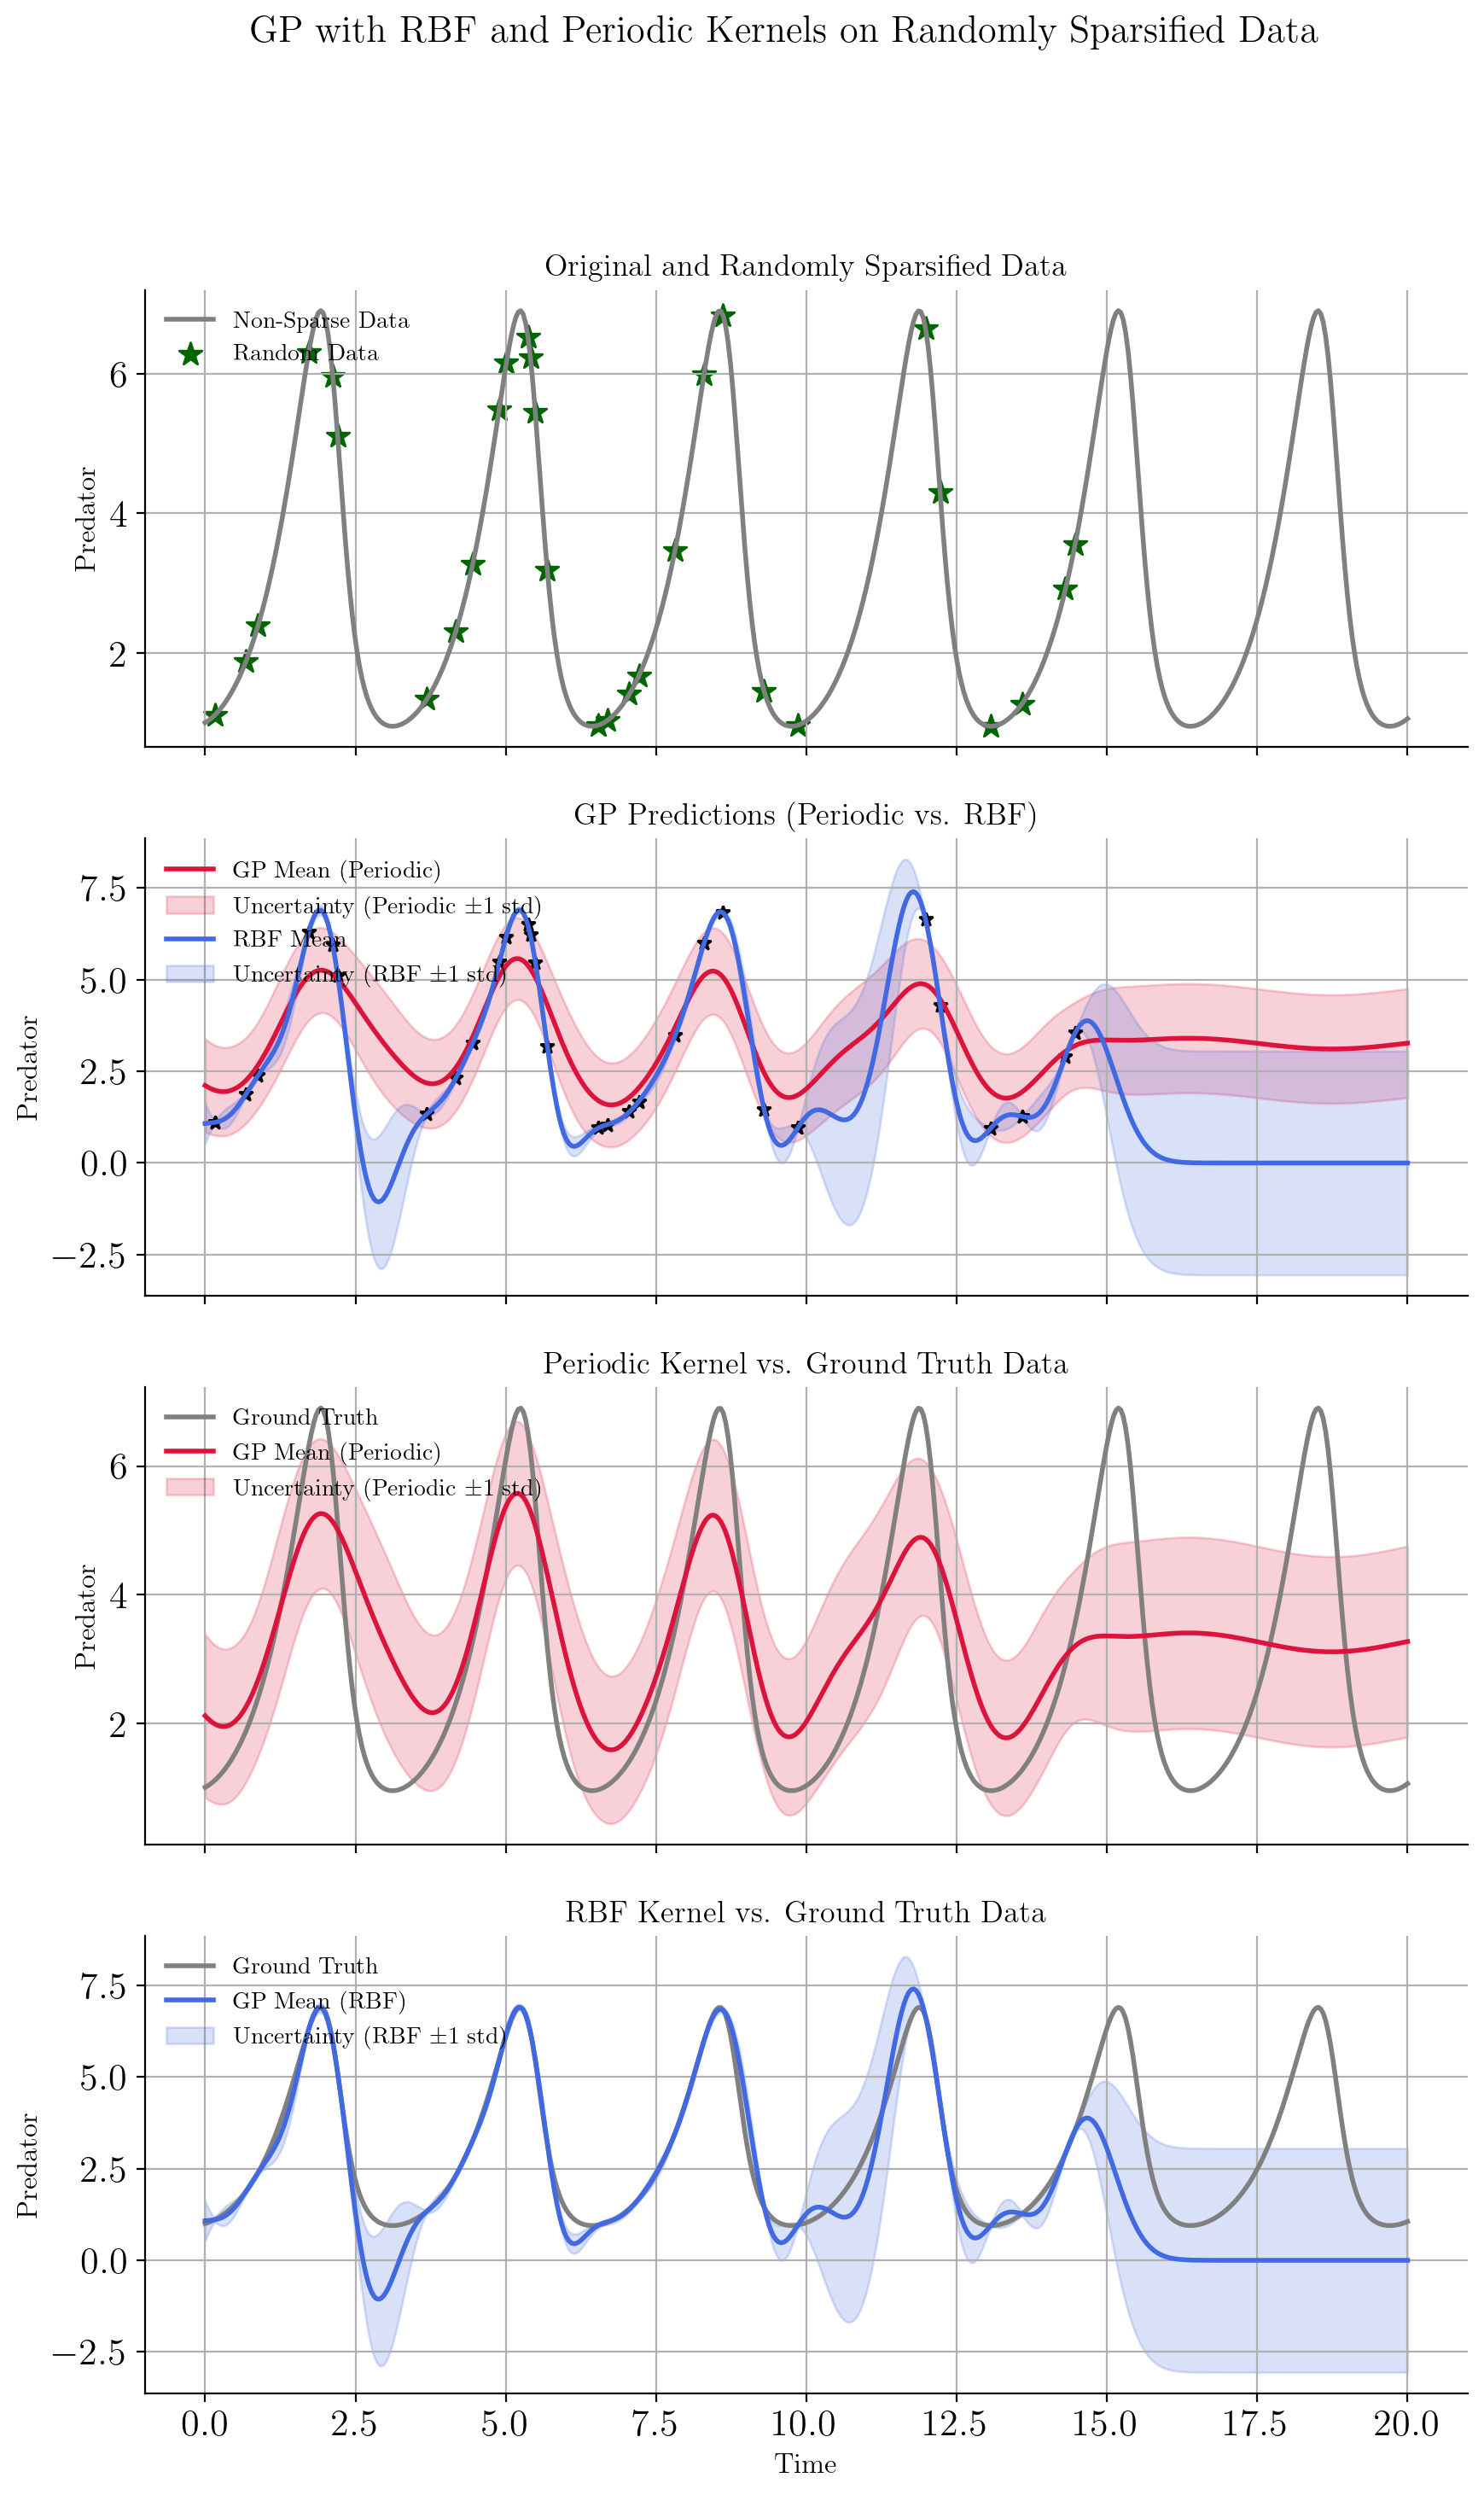

In [197]:
import matplotlib.pyplot as plt

# Create figure and 4 subplots (vertically stacked)
fig, axs = plt.subplots(4, 1, figsize=(10, 16), sharex=True)
fig.suptitle("GP with RBF and Periodic Kernels on Randomly Sparsified Data", fontsize=16)

# ----------------------------------
# Subplot 1: Original Data
# ----------------------------------
axs[0].plot(t, predator, color='gray', lw=2, label='Non-Sparse Data')
axs[0].scatter(
    t_random_tensor, 
    predator_random_tensor.numpy(),
    marker='*', 
    s=100, 
    color='darkgreen', 
    label='Random Data'
)
axs[0].grid(True)
axs[0].set_ylabel('Predator', fontsize=12)
axs[0].legend(loc='upper left', fontsize=10)
axs[0].set_title('Original and Randomly Sparsified Data', fontsize=13)

# -----------------------------------------------------
# Subplot 2: GP Predictions (Periodic vs. RBF) - Combined
# -----------------------------------------------------
# Plot random data points
axs[1].plot(t_random_tensor, predator_random_tensor, 'k*')

# Periodic kernel predictions
axs[1].plot(
    t.numpy(), 
    periodic_mean_random.numpy(),
    color='crimson', 
    lw=2, 
    label='GP Mean (Periodic)'
)
axs[1].fill_between(
    t.numpy(),
    (periodic_mean_random - periodic_std_random).numpy(),
    (periodic_mean_random + periodic_std_random).numpy(),
    color='crimson', 
    alpha=0.2, 
    label='Uncertainty (Periodic ±1 std)'
)

# RBF kernel predictions
axs[1].plot(
    t.numpy(), 
    mean_random.numpy(),
    color='royalblue', 
    lw=2, 
    label='RBF Mean'
)
axs[1].fill_between(
    t.numpy(),
    (mean_random - std_random).numpy(),
    (mean_random + std_random).numpy(),
    color='royalblue', 
    alpha=0.2, 
    label='Uncertainty (RBF ±1 std)'
)
axs[1].grid(True)
axs[1].set_ylabel('Predator', fontsize=12)
axs[1].legend(loc='upper left', fontsize=10)
axs[1].set_title('GP Predictions (Periodic vs. RBF)', fontsize=13)

# ----------------------------------------------------
# Subplot 3: Periodic Kernel vs. Ground Truth Data
# ----------------------------------------------------
# Ground truth data
axs[2].plot(t, predator, color='gray', lw=2, label='Ground Truth')
# Overlay periodic kernel predictions
axs[2].plot(
    t.numpy(), 
    periodic_mean_random.numpy(),
    color='crimson', 
    lw=2, 
    label='GP Mean (Periodic)'
)
axs[2].fill_between(
    t.numpy(),
    (periodic_mean_random - periodic_std_random).numpy(),
    (periodic_mean_random + periodic_std_random).numpy(),
    color='crimson', 
    alpha=0.2, 
    label='Uncertainty (Periodic ±1 std)'
)
axs[2].grid(True)
axs[2].set_ylabel('Predator', fontsize=12)
axs[2].legend(loc='upper left', fontsize=10)
axs[2].set_title('Periodic Kernel vs. Ground Truth Data', fontsize=13)

# ----------------------------------------------------
# Subplot 4: RBF Kernel vs. Ground Truth Data
# ----------------------------------------------------
# Ground truth data
axs[3].plot(t, predator, color='gray', lw=2, label='Ground Truth')
# Overlay RBF kernel predictions
axs[3].plot(
    t.numpy(), 
    mean_random.numpy(),
    color='royalblue', 
    lw=2, 
    label='GP Mean (RBF)'
)
axs[3].fill_between(
    t.numpy(),
    (mean_random - std_random).numpy(),
    (mean_random + std_random).numpy(),
    color='royalblue', 
    alpha=0.2, 
    label='Uncertainty (RBF ±1 std)'
)
axs[3].grid(True)
axs[3].set_xlabel('Time', fontsize=12)
axs[3].set_ylabel('Predator', fontsize=12)
axs[3].legend(loc='upper left', fontsize=10)
axs[3].set_title('RBF Kernel vs. Ground Truth Data', fontsize=13)

# Adjust layout to fit the main title
# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# TODO - Check the final mll value at the end of training (Why do we fit to a certain mll). Why is periodic fitting to a un-ideal period (small wiggles not represneting the actualy data periodicity) is this theoretic vs practical
# TODO - Create the kernel plots (2d heat maps from the kernel cookbook)
# TODO - Start putting together thoughts and ancedotes about the things that I am doing (overleaf). Add some figures and math behind the Mauna Loa data. 
# TODO - alpha parameter in sklearn gp helping to make matrix not ~singular (https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)
# TODO - FIgure out what is going on regarding Sklearn White noise kernel vs Gpytorch likelihood
# TODO - Look into constrainting the gp to not give negative dead people

In [ ]:
model_period.covar_module()